In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [37]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_LATENT.mkdir(parents=True, exist_ok=True)

X = np.load(DATA_PROCESSED / "X_windows.npy")

X.shape

(70080, 60, 6)

In [38]:
n_samples, window, n_features = X.shape
input_dim = window * n_features

X_flat = X.reshape(n_samples, input_dim).astype(np.float32)

X_flat.shape

(70080, 360)

In [39]:
train_ratio = 0.8
n_train = int(train_ratio * len(X_flat))

X_train = X_flat[:n_train]
X_val = X_flat[n_train:]

X_train.shape, X_val.shape

((56064, 360), (14016, 360))

In [40]:
X_train_tensor = torch.tensor(X_train)
X_val_tensor = torch.tensor(X_val)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=256,
    shuffle=False
)

In [41]:
class FullyConnectedVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, hidden_dims=[128, 64]):
        super().__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        encoder_layers = []
        prev_dim = input_dim

        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(nn.ReLU())
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        self.mu_layer = nn.Linear(prev_dim, latent_dim)
        self.logvar_layer = nn.Linear(prev_dim, latent_dim)

        # Decoder
        decoder_layers = []
        prev_dim = latent_dim

        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(nn.ReLU())
            prev_dim = h_dim

        decoder_layers.append(nn.Linear(prev_dim, input_dim))

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [42]:
def vae_loss(x, x_recon, mu, logvar, beta=1e-3):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [44]:
latent_dim = 8

model = FullyConnectedVAE(
    input_dim=input_dim,
    latent_dim=latent_dim,
    hidden_dims=[128, 64]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [45]:
n_epochs = 50
beta = 1e-3

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
}

for epoch in range(n_epochs):
    model.train()

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(
            x, x_recon, mu, logvar, beta=beta
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(x)
        train_recon += recon_loss.item() * len(x)
        train_kl += kl_loss.item() * len(x)

    train_loss /= len(X_train_tensor)
    train_recon /= len(X_train_tensor)
    train_kl /= len(X_train_tensor)

    model.eval()

    val_loss = 0.0
    val_recon = 0.0
    val_kl = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)

            x_recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(
                x, x_recon, mu, logvar, beta=beta
            )

            val_loss += loss.item() * len(x)
            val_recon += recon_loss.item() * len(x)
            val_kl += kl_loss.item() * len(x)

    val_loss /= len(X_val_tensor)
    val_recon /= len(X_val_tensor)
    val_kl /= len(X_val_tensor)

    history["train_loss"].append(train_loss)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["val_loss"].append(val_loss)
    history["val_recon"].append(val_recon)
    history["val_kl"].append(val_kl)

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss: {train_loss:.6f} | "
            f"val loss: {val_loss:.6f} | "
            f"train recon: {train_recon:.6f} | "
            f"val recon: {val_recon:.6f} | "
            f"KL: {val_kl:.6f}"
        )

Epoch 000 | train loss: 0.461539 | val loss: 0.339153 | train recon: 0.442375 | val recon: 0.315586 | KL: 23.567541
Epoch 005 | train loss: 0.264257 | val loss: 0.277905 | train recon: 0.245339 | val recon: 0.257925 | KL: 19.979156
Epoch 010 | train loss: 0.259296 | val loss: 0.275675 | train recon: 0.240540 | val recon: 0.256243 | KL: 19.432898
Epoch 015 | train loss: 0.256639 | val loss: 0.274989 | train recon: 0.237894 | val recon: 0.255578 | KL: 19.411411
Epoch 020 | train loss: 0.254798 | val loss: 0.274097 | train recon: 0.236083 | val recon: 0.254799 | KL: 19.297471
Epoch 025 | train loss: 0.253293 | val loss: 0.274390 | train recon: 0.234569 | val recon: 0.254973 | KL: 19.417169
Epoch 030 | train loss: 0.251996 | val loss: 0.274430 | train recon: 0.233288 | val recon: 0.255156 | KL: 19.273753
Epoch 035 | train loss: 0.250922 | val loss: 0.275156 | train recon: 0.232202 | val recon: 0.255923 | KL: 19.232939
Epoch 040 | train loss: 0.249976 | val loss: 0.275055 | train recon: 0.2

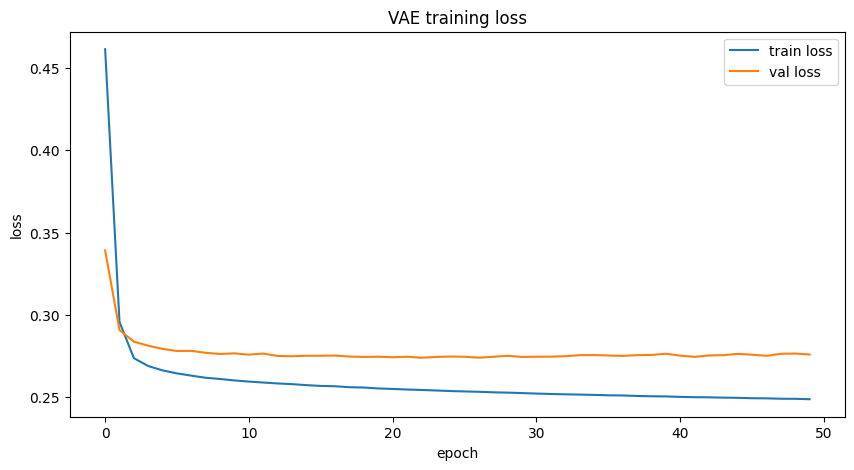

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("VAE training loss")
plt.legend()
plt.show()

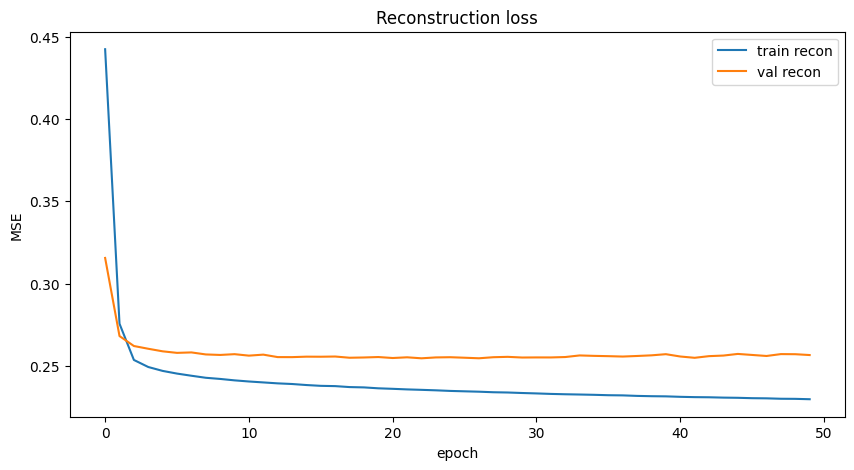

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_recon"], label="train recon")
plt.plot(history["val_recon"], label="val recon")

plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Reconstruction loss")
plt.legend()
plt.show()

In [48]:
model.eval()

idx = 0

x = X_val_tensor[idx:idx+1].to(device)

with torch.no_grad():
    x_recon, mu, logvar = model(x)

x_np = x.cpu().numpy().reshape(window, n_features)
x_recon_np = x_recon.cpu().numpy().reshape(window, n_features)

In [49]:
feature_names = np.load(DATA_PROCESSED / "feature_names.npy", allow_pickle=True)

feature_names

array(['momentum_120', 'momentum_20', 'momentum_60', 'return_1d',
       'volatility_20', 'volatility_60'], dtype='<U13')

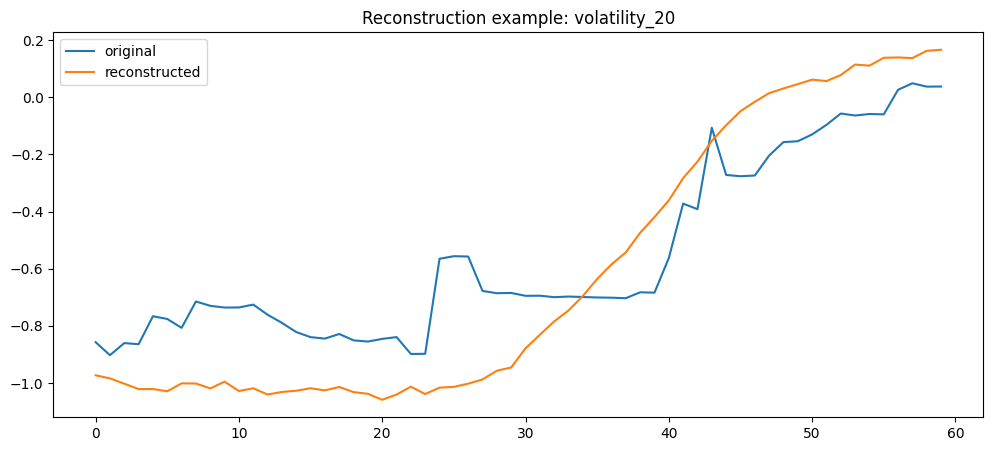

In [52]:
feature_idx = 4

plt.figure(figsize=(12, 5))

plt.plot(x_np[:, feature_idx], label="original")
plt.plot(x_recon_np[:, feature_idx], label="reconstructed")

plt.title(f"Reconstruction example: {feature_names[feature_idx]}")
plt.legend()
plt.show()

In [53]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim,
        "window": window,
        "n_features": n_features,
        "latent_dim": latent_dim,
        "hidden_dims": [128, 64],
        "beta": beta,
        "history": history,
    },
    MODELS_DIR / "fc_vae.pt"
)

In [18]:
all_loader = DataLoader(
    TensorDataset(torch.tensor(X_flat)),
    batch_size=512,
    shuffle=False
)

Z_list = []

model.eval()

with torch.no_grad():
    for batch in all_loader:
        x = batch[0].to(device)
        mu, logvar = model.encode(x)
        Z_list.append(mu.cpu().numpy())

Z = np.concatenate(Z_list, axis=0)

Z.shape

(70080, 8)

In [19]:
np.save(DATA_LATENT / "Z_fc_vae.npy", Z)

In [54]:
sample_dates = np.load(DATA_PROCESSED / "sample_dates.npy", allow_pickle=True)
sample_tickers = np.load(DATA_PROCESSED / "sample_tickers.npy", allow_pickle=True)

latent_df = pd.DataFrame(
    Z,
    columns=[f"z_{i}" for i in range(Z.shape[1])]
)

latent_df["date"] = sample_dates
latent_df["ticker"] = sample_tickers

latent_df = latent_df[["date", "ticker"] + [f"z_{i}" for i in range(Z.shape[1])]]

latent_df.head()

,date,ticker,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.619362,-0.291282,1.218507,-1.537995,-0.378683,-0.759858,0.066653,-0.840747
1,2015-09-22,AAPL,-0.727026,-0.177698,1.383948,-1.456320,-0.351501,-0.799361,-0.037340,-0.873263
2,2015-09-23,AAPL,-0.811343,-0.079573,1.356158,-1.388889,-0.337329,-0.717278,-0.089436,-0.947264
3,2015-09-24,AAPL,-0.956392,0.021238,1.388825,-1.334907,-0.281220,-0.718173,-0.138247,-0.959101
4,2015-09-25,AAPL,-1.019286,0.120451,1.327576,-1.271330,-0.350556,-0.711358,-0.211038,-0.988253


In [55]:
latent_df.to_parquet(DATA_LATENT / "fc_vae_latents.parquet")